In [1]:
url = "https://github.com/ArinB/MSBA-CA-03-Decision-Trees/blob/master/census_data.csv?raw=true"

In [2]:
import pandas as pd

df = pd.read_csv(url)

In [5]:
df.shape

(48842, 11)

In [6]:
df.head()

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,b. 31-40,b. Mid - Low,b. Mid,c. > 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,train,0
1,a. 0-30,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,train,0
2,b. 31-40,a. Low,b. Mid,a. = 0,c. High,b. 9-12,b. Mid,b. income,d. 36-40 & 56-60,train,0
3,b. 31-40,a. Low,c. High,a. = 0,b. Mid,a. 0-8,a. Low,b. income,e. 40-55,train,0
4,b. 31-40,e. High,c. High,a. = 0,a. Low,c. 13,c. Bachelors,b. income,b. 26-30 & 71-100,train,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   hours_per_week_bin  48842 non-null  object
 1   occupation_bin      48842 non-null  object
 2   msr_bin             48842 non-null  object
 3   capital_gl_bin      48842 non-null  object
 4   race_sex_bin        48842 non-null  object
 5   education_num_bin   48842 non-null  object
 6   education_bin       48842 non-null  object
 7   workclass_bin       48842 non-null  object
 8   age_bin             48842 non-null  object
 9   flag                48842 non-null  object
 10  y                   48842 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 4.1+ MB


In [9]:
df.nunique()

,0
hours_per_week_bin,5
occupation_bin,5
msr_bin,3
capital_gl_bin,3
race_sex_bin,3
education_num_bin,5
education_bin,5
workclass_bin,2
age_bin,5
flag,2


In [14]:
#categorical bins are gonna be flag and y, categorical predictors are: hours_per_week_bin, education_num_bin, occuaption_bin, msr_bin, and race_sex_bin
for col in df.columns:
    print(col, "->", df[col].astype(str).head(5).tolist())


hours_per_week_bin -> ['b. 31-40', 'a. 0-30', 'b. 31-40', 'b. 31-40', 'b. 31-40']
occupation_bin -> ['b. Mid - Low', 'e. High', 'a. Low', 'a. Low', 'e. High']
msr_bin -> ['b. Mid', 'c. High', 'b. Mid', 'c. High', 'c. High']
capital_gl_bin -> ['c. > 0', 'a. = 0', 'a. = 0', 'a. = 0', 'a. = 0']
race_sex_bin -> ['c. High', 'c. High', 'c. High', 'b. Mid', 'a. Low']
education_num_bin -> ['c. 13', 'c. 13', 'b. 9-12', 'a. 0-8', 'c. 13']
education_bin -> ['c. Bachelors', 'c. Bachelors', 'b. Mid', 'a. Low', 'c. Bachelors']
workclass_bin -> ['b. income', 'b. income', 'b. income', 'b. income', 'b. income']
age_bin -> ['d. 36-40 & 56-60', 'e. 40-55', 'd. 36-40 & 56-60', 'e. 40-55', 'b. 26-30 & 71-100']
flag -> ['train', 'train', 'train', 'train', 'train']
y -> ['0', '0', '0', '0', '0']


Q1) Discretization is useful because decision trees split data based on categorical values, and the model itself naturally handles categorical data better than raw continuous values.

Q2) If we did not discretizate the tree could easily overfit since it could use numbers such as 9.5, 10.75, and 12 instead of a bin that is 9-12. This could also lead to the model memorizing data instead of the patterns demonstrated by the bins. Considering the decision tree can become unstable with small variations, a small value change can affect the entire tree structure, and with more splits the more complicated tree we would have. Hence why not using continuous values is key here.

In [15]:
train_df = df[df['flag']=='train']
test_df = df[df['flag']=='test']

print(train_df.shape)
print(test_df.shape)

(32561, 11)
(16281, 11)


Beginning of part 2

In [16]:
df.isnull().sum() #ok zero nulls

,0
hours_per_week_bin,0
occupation_bin,0
msr_bin,0
capital_gl_bin,0
race_sex_bin,0
education_num_bin,0
education_bin,0
workclass_bin,0
age_bin,0
flag,0


In [17]:
df.isna().sum() #zero nas

,0
hours_per_week_bin,0
occupation_bin,0
msr_bin,0
capital_gl_bin,0
race_sex_bin,0
education_num_bin,0
education_bin,0
workclass_bin,0
age_bin,0
flag,0


In [18]:
df.duplicated().sum()

np.int64(40012)

In [22]:
df.duplicated().sum() / len(df)


np.float64(0.819212972441751)

In [19]:
for col in df.columns:
    print(col, df[col].nunique())


hours_per_week_bin 5
occupation_bin 5
msr_bin 3
capital_gl_bin 3
race_sex_bin 3
education_num_bin 5
education_bin 5
workclass_bin 2
age_bin 5
flag 2
y 2


In [20]:
df.describe(include="all")

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
count,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842.000000
unique,5,5,3,3,3,5,5,2,5,2,NaN
top,b. 31-40,c. Mid - Mid,c. High,a. = 0,c. High,b. 9-12,b. Mid,b. income,e. 40-55,train,NaN
freq,26639,13971,22047,42525,29737,30324,30324,46012,13963,32561,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.239282
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.426649
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [21]:
for col in df.columns:
    print(df[col].value_counts())
    print("\n")


hours_per_week_bin
b. 31-40            26639
d. 41-50 & 61-70     9819
a. 0-30              7851
e. 51-60             3759
c. 71-100             774
Name: count, dtype: int64


occupation_bin
c. Mid - Mid     13971
b. Mid - Low     12947
e. High          12258
a. Low            7237
d. Mid - High     2429
Name: count, dtype: int64


msr_bin
c. High    22047
b. Mid     15868
a. Low     10927
Name: count, dtype: int64


capital_gl_bin
a. = 0    42525
c. > 0     4035
b. < 0     2282
Name: count, dtype: int64


race_sex_bin
c. High    29737
b. Mid     16457
a. Low      2648
Name: count, dtype: int64


education_num_bin
b. 9-12    30324
c. 13       8025
a. 0-8      6408
d. 14       2657
e. 15+      1428
Name: count, dtype: int64


education_bin
b. Mid          30324
c. Bachelors     8025
a. Low           6408
d. Masters       2657
e. High          1428
Name: count, dtype: int64


workclass_bin
b. income       46012
a. no income     2830
Name: count, dtype: int64


age_bin
e. 40-55          

Part 2 report:
The dataset had no missing values, but a high percentage of duplicate rows, this is not to fear as in sensus data this is extremely normal. A lot of the data is categorical bins so there are a very low number of possible combinations. This can actually be helpful for the decision tree since it reinforces partterns and improve the split reliability. No real issues, only notable thing is our y, 37155 is about 76% which is heavily imbalanced, our model could predict 0 and still get 76% accuracy.

In [ ]:
#beginning of part 3

In [23]:
x= df.drop(columns=["y"])
y = df["y"]

In [25]:
x_train = train_df.drop(columns=["y","flag"])
y_train = train_df["y"]

In [26]:
x_test = test_df.drop(columns=["y","flag"])
y_test = test_df["y"]

In [28]:
x_train = pd.get_dummies(x_train)
x_test  = pd.get_dummies(x_test)


In [30]:
from sklearn.tree import DecisionTreeClassifier



In [32]:
model = DecisionTreeClassifier(random_state=101)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=101)

In [34]:
y_prediction = model.predict(x_test)


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [36]:
accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(y_test, y_prediction)
recall = recall_score(y_test, y_prediction)
f1 = f1_score(y_test, y_prediction)
cm = confusion_matrix(y_test, y_prediction)

accuracy, precision, recall, f1, cm


(0.8364351084085744,
 0.6922326941826454,
 0.5538221528861155,
 0.6153401704463383,
 array([[11488,   947],
        [ 1716,  2130]]))

Accuracy is high but lets remember our dataset is imbalanced. Precision is 69% so that's strong for predicting income greater than 50k. And our recall for predicting high-income individuals is 55% meaning we are missing almost half of them. Our F1 is moderate with 0.62 reflecting overall performance. Our tree is curetnly predicting less than or equal to 50k better because that class dominates in numbers, again this is expected for our imbalanced data. It can definitely be improved with hyperparameter tuning.

In [ ]:
#beginitting part 5

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

def eval_tree(params, X_train, y_train, X_test, y_test, random_state=101):
    model = DecisionTreeClassifier(random_state=random_state, **params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "params": params,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

def results_to_df(results):
    # confusion matrix can’t live cleanly in a dataframe cell for viewing; keep separately
    rows = []
    for r in results:
        row = {**r["params"],
               "accuracy": r["accuracy"],
               "precision": r["precision"],
               "recall": r["recall"],
               "f1": r["f1"]}
        rows.append(row)
    return pd.DataFrame(rows).sort_values("accuracy", ascending=False)


In [39]:
run1_results = []
for crit in ["gini", "entropy"]:
    run1_results.append(eval_tree({"criterion": crit}, x_train, y_train, x_test, y_test))

run1_df = results_to_df(run1_results)
run1_df


,criterion,accuracy,precision,recall,f1
0,gini,0.836435,0.692233,0.553822,0.615340
1,entropy,0.835575,0.688366,0.555382,0.614765


In [40]:
best_criterion = run1_df.iloc[0]["criterion"]
best_criterion


'gini'

In [42]:
#run 2
min_leaf_values = [1, 2, 5, 10, 20, 50, 100]

run2_results = []
for m in min_leaf_values:
    run2_results.append(eval_tree(
        {"criterion": best_criterion, "min_samples_leaf": m},
        x_train, y_train, x_test, y_test
    ))

run2_df = results_to_df(run2_results)
run2_df


,criterion,min_samples_leaf,accuracy,precision,recall,f1
4,gini,20,0.844051,0.714755,0.565523,0.631441
5,gini,50,0.842393,0.718281,0.547582,0.621422
6,gini,100,0.841165,0.726131,0.526001,0.610072
3,gini,10,0.839998,0.701789,0.561102,0.623609
2,gini,5,0.838831,0.699282,0.557462,0.620370
1,gini,2,0.837356,0.696651,0.551742,0.615786
0,gini,1,0.836435,0.692233,0.553822,0.615340


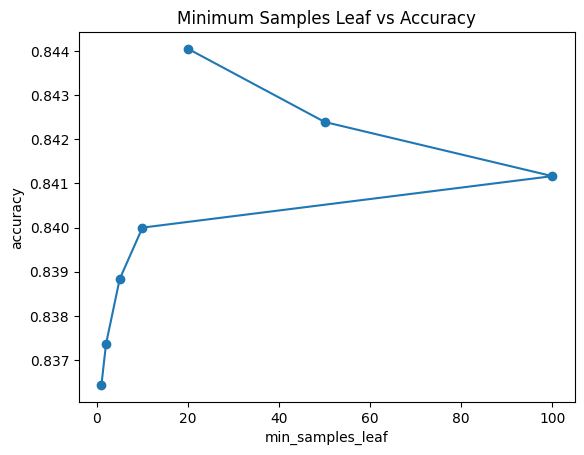

In [43]:
plt.figure()
plt.plot(run2_df["min_samples_leaf"], run2_df["accuracy"], marker="o")
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.title("Minimum Samples Leaf vs Accuracy")
plt.show()


In [44]:
best_min_samples_leaf = int(run2_df.iloc[0]["min_samples_leaf"])
best_min_samples_leaf


20

In [46]:
#run 3
max_feat_values = [None, "sqrt", "log2", 0.3, 0.5, 0.7, 1.0]

run3_results = []
for mf in max_feat_values:
    run3_results.append(eval_tree(
        {"criterion": best_criterion, "min_samples_leaf": best_min_samples_leaf, "max_features": mf},
        x_train, y_train, x_test, y_test
    ))

run3_df = results_to_df(run3_results)
run3_df


,criterion,min_samples_leaf,max_features,accuracy,precision,recall,f1
0,gini,20,None,0.844051,0.714755,0.565523,0.631441
6,gini,20,1.0,0.844051,0.714755,0.565523,0.631441
3,gini,20,0.3,0.843929,0.720812,0.553822,0.626378
5,gini,20,0.7,0.843437,0.717544,0.556162,0.626630
4,gini,20,0.5,0.843191,0.706616,0.574883,0.633978
2,gini,20,log2,0.833733,0.682942,0.552782,0.611007
1,gini,20,sqrt,0.832197,0.685296,0.535621,0.601284


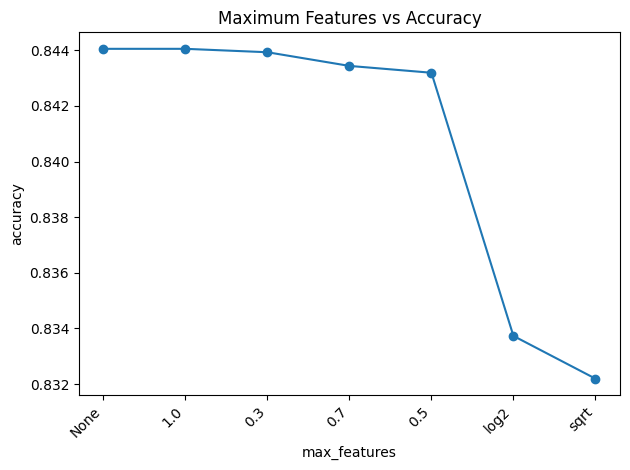

In [47]:
# Make x labels readable
x_labels = run3_df["max_features"].astype(str)

plt.figure()
plt.plot(range(len(run3_df)), run3_df["accuracy"], marker="o")
plt.xticks(range(len(run3_df)), x_labels, rotation=45, ha="right")
plt.xlabel("max_features")
plt.ylabel("accuracy")
plt.title("Maximum Features vs Accuracy")
plt.tight_layout()
plt.show()


In [49]:
best_max_features = run3_df.iloc[0]["max_features"]
print(best_max_features)

None


In [51]:
depth_values = [None, 3, 5, 7, 10, 15, 20, 30]

run4_results = []
for d in depth_values:
    run4_results.append(eval_tree(
        {"criterion": best_criterion,
         "min_samples_leaf": best_min_samples_leaf,
         "max_features": best_max_features,
         "max_depth": d},
        x_train, y_train, x_test, y_test
    ))

run4_df = results_to_df(run4_results)
run4_df


,criterion,min_samples_leaf,max_features,max_depth,accuracy,precision,recall,f1
4,gini,20,None,10.0,0.845955,0.718342,0.572283,0.637048
0,gini,20,None,NaN,0.844051,0.714755,0.565523,0.631441
5,gini,20,None,15.0,0.844051,0.714755,0.565523,0.631441
6,gini,20,None,20.0,0.844051,0.714755,0.565523,0.631441
7,gini,20,None,30.0,0.844051,0.714755,0.565523,0.631441
3,gini,20,None,7.0,0.843621,0.701488,0.588404,0.639989
2,gini,20,None,5.0,0.835759,0.675870,0.585543,0.627473
1,gini,20,None,3.0,0.828880,0.669437,0.544462,0.600516


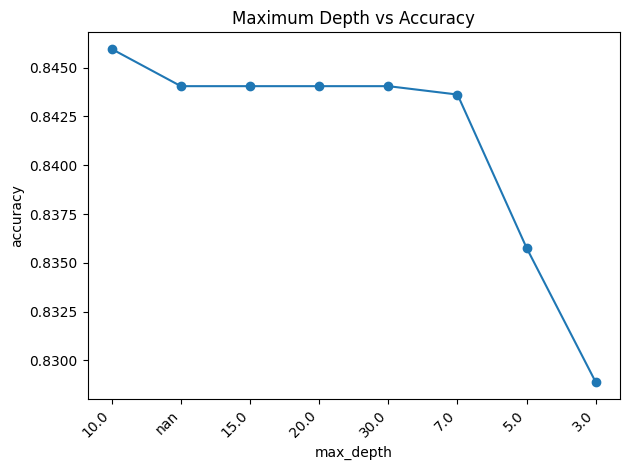

In [52]:
x_labels = run4_df["max_depth"].astype(str)

plt.figure()
plt.plot(range(len(run4_df)), run4_df["accuracy"], marker="o")
plt.xticks(range(len(run4_df)), x_labels, rotation=45, ha="right")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Maximum Depth vs Accuracy")
plt.tight_layout()
plt.show()


In [59]:
best_max_depth = run4_df.iloc[0]["max_depth"]
if best_max_depth is not None:
    best_max_depth = int(best_max_depth)

In [60]:
best_params = {
    "criterion": best_criterion,
    "min_samples_leaf": best_min_samples_leaf,
    "max_features": best_max_features,
    "max_depth": best_max_depth
}

best_result = eval_tree(best_params, x_train, y_train, x_test, y_test)
best_params, best_result["accuracy"], best_result["precision"], best_result["recall"], best_result["f1"], best_result["confusion_matrix"]


({'criterion': 'gini',
  'min_samples_leaf': 20,
  'max_features': None,
  'max_depth': 10},
 0.8459554081444629,
 0.7183420365535248,
 0.5722828913156526,
 0.6370477568740955,
 array([[11572,   863],
        [ 1645,  2201]]))

Q3) The optimal Decision Tree model was built by using criterion = gini, min_samples_leaf = 20, max_features = None, and max_depth =10. The hyperparameters helped greatly, the min_samples_leaf of 20 prevented the tiniest leaf nodes which reduces overfitting. The max_depth limited the tree complexity. Accuracy not only increased but all measures went up, these improvements show how the tuning reduced overfitting and led to a model that better represents the unseen data due to our original imbalance.

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

depth_values = [2, 4, 6, 8, 10, 12, 14, 16]

rows = []

for d in depth_values:
    model = DecisionTreeClassifier(
        criterion="gini",
        min_samples_leaf=20,
        max_features=None,
        max_depth=d,
        random_state=101
    )
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    rows.append({
        "Maximum Depth": d,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    })

depth_table = pd.DataFrame(rows)
depth_table


,Maximum Depth,Accuracy,Recall,Precision,F1 Score
0,2,0.816596,0.397816,0.695455,0.506120
1,4,0.827590,0.463859,0.705417,0.559686
2,6,0.840550,0.584763,0.692426,0.634057
3,8,0.843314,0.555122,0.717647,0.626008
4,10,0.845955,0.572283,0.718342,0.637048
5,12,0.844420,0.576963,0.710080,0.636637
6,14,0.843744,0.568383,0.712052,0.632157
7,16,0.844051,0.565523,0.714755,0.631441


In [61]:
#part 6
!pip install graphviz

In [62]:
from sklearn.tree import export_graphviz
import graphviz

In [64]:
best_model = DecisionTreeClassifier(
    criterion="gini",
    min_samples_leaf=20,
    max_features=None,
    max_depth=10,
    random_state=101
)

best_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=101)

In [67]:
!apt-get update -qq
!apt-get install -y graphviz
!dot -V
#had to troubleshoot with chat

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 76 not upgraded.
dot - graphviz version 2.43.0 (0)


In [75]:
# Make Graphviz-safe feature names (removes characters that break DOT syntax)
safe_feature_names = (
    x_train.columns
    .astype(str)
    .str.replace("[", "(", regex=False)
    .str.replace("]", ")", regex=False)
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
)


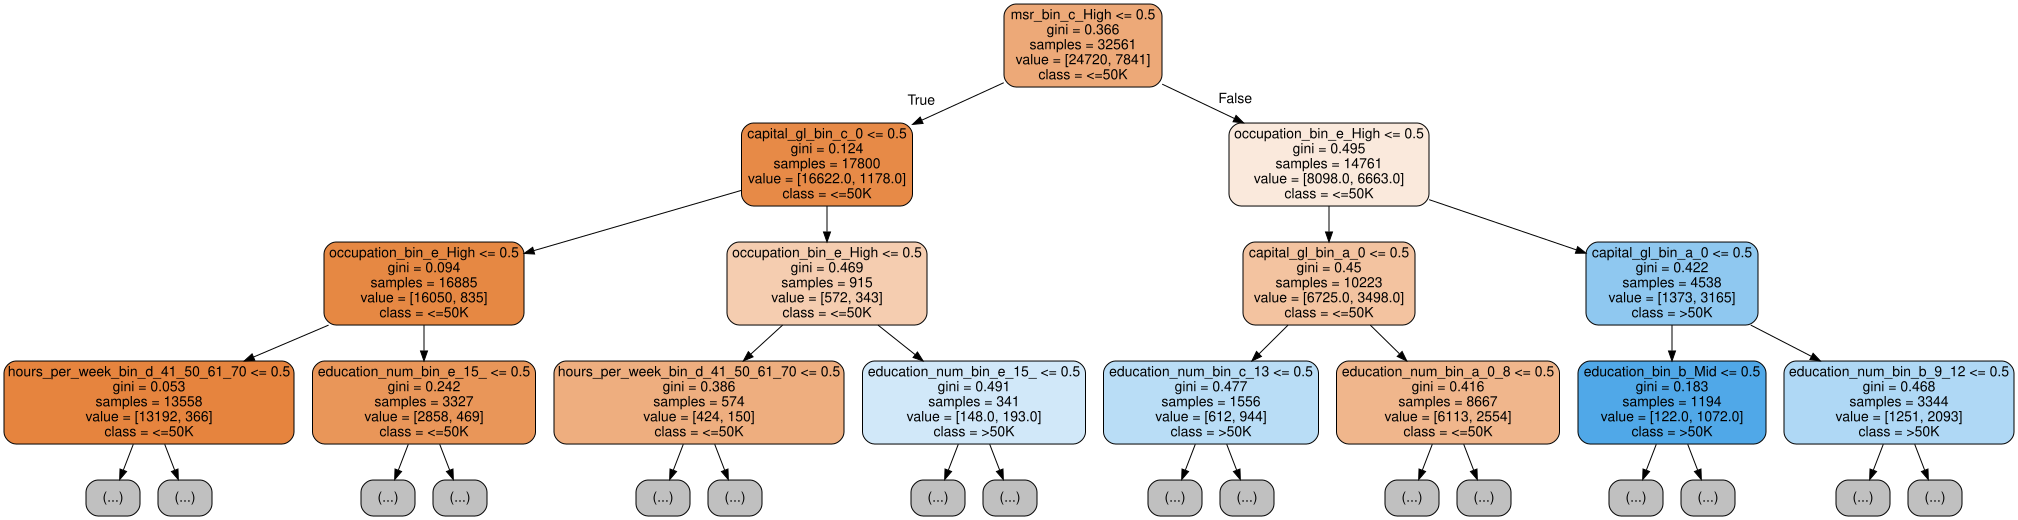

In [79]:
import re
from sklearn.tree import export_graphviz
import graphviz

def make_dot_safe(name: str) -> str:
    # keep only letters, numbers, underscore
    return re.sub(r'[^0-9a-zA-Z_]+', '_', str(name))

safe_feature_names = [make_dot_safe(c) for c in x_train.columns]

dot_data = export_graphviz(
    best_model,
    out_file=None,
    feature_names=safe_feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    special_characters=False,  # important: reduces DOT escaping issues
    max_depth=3                # keep it renderable
)

graphviz.Source(dot_data)


In [82]:
root_idx = best_model.tree_.feature[0]
root_feature = x_train.columns[root_idx]
root_feature

'msr_bin_c. High'

In [84]:
import pandas as pd

fi = pd.Series(best_model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
fi.head(10)
#for q6 msr_bin_c being almost .48 is massive, thats very high, so MSR is our strongest predictor of income level

,0
msr_bin_c. High,0.475371
occupation_bin_e. High,0.179148
capital_gl_bin_a. = 0,0.077025
education_num_bin_a. 0-8,0.038554
capital_gl_bin_c. > 0,0.036653
education_bin_b. Mid,0.025475
age_bin_e. 40-55,0.019179
hours_per_week_bin_a. 0-30,0.017728
education_num_bin_b. 9-12,0.015099
age_bin_d. 36-40 & 56-60,0.012017


In [87]:
import time

start = time.time()

best_model = DecisionTreeClassifier(
    criterion="gini",
    min_samples_leaf=20,
    max_features=None,
    max_depth=10,
    random_state=101
)

best_model.fit(x_train, y_train)

end = time.time()
runtime = end - start
runtime


0.3362154960632324

Q4 our total runtime was approximately 34 seconds, this was due to the fact our process was efficient because our decision tree scales well with categorical features and our model depth was limited which reduces training complexity.

Q5 Yes

Q6) The visualization of the decision treee shows that the root node splots on the MSR category, indicating this variable is our strongest predictor of income classification. Feature importance analysis confirms this since MSR contributes to nearly half our total predictive power. Our next most influential variables are occupation category and capital gain status, neither is nearly as strong as MSR but they suggest employment strongly infleunces income prediction.

Q7 No this tree is unlikely to overfit because it is not fully grown aand we have put in contraints.

In [90]:
#part 8
new_ind = pd.DataFrame([{
    "hours_per_week_bin": "c. 41-50",
    "occupation_bin": "b. Mid - Low",
    "msr_bin": "c. High",
    "capital_gl_bin": "c. > 0",
    "race_sex_bin": "b. Mid",
    "education_num_bin": "b. 9-12",
    "education_bin": "e. High",
    "workclass_bin": "b. income",
    "age_bin": "d. 36-40 & 56-60"
}])


In [91]:
new_encoded = pd.get_dummies(new_ind)

In [93]:
new_encoded = new_encoded.reindex(columns=x_train.columns, fill_value=0)

In [94]:
prediction = best_model.predict(new_encoded)
prediction

array([1])

In [95]:
prob = best_model.predict_proba(new_encoded)
prob

array([[0.28858025, 0.71141975]])

In [96]:
probability = prob.max()
probability

np.float64(0.7114197530864198)

Q8 The predicted income category is >50k, and the model's probability for this prediction is 71%.